# 🏔️ Quantum Ascent — Basecamp 1: The Qubit & Superposition

<div style="border-left:5px solid #7c3aed;background:#f5f3ff;color:#2e1065;padding:12px 16px;border-radius:4px">
<b>📋 Mission briefing.</b> Classical bits answer <i>yes</i> or <i>no</i>. Qubits hold something richer: a pair of <b>amplitudes</b> that only turn into yes/no when you look. Your mission: build your first quantum states, predict their measurement statistics <i>before</i> running them, and verify your predictions on a real quantum simulator.
</div>

**By the end of this basecamp you can:**
- Describe a qubit state as a 2-amplitude vector and explain why the 'both 0 and 1 at once' slogan is misleading
- Use the Born rule to predict measurement probabilities from amplitudes
- Build and run your first Qiskit circuit and read measurement counts
- Prepare a state with any target measurement probability using a rotation gate

*Estimated time: 45 min · Best experienced with the [course website](https://quantum-ascent-77617.web.app) open in another tab.*

$
\gdef\ket#1{|#1\rangle}
\gdef\bra#1{\langle #1|}
\gdef\braket#1#2{\langle #1|#2\rangle}
\gdef\sqrttwo{\tfrac{1}{\sqrt{2}}}
\gdef\mymatrix#1#2{\begin{pmatrix} #2 \end{pmatrix}}
\gdef\myvector#1{\begin{pmatrix} #1 \end{pmatrix}}
\gdef\hadamard{\sqrttwo\mymatrix{}{1 & 1 \\ 1 & -1}}
$
<i>This cell defines the math notation used below — if formulas look broken,
run (or re-render) this cell first.</i>

In [1]:
# ✅ Setup — run me first! (works locally and on Google Colab)
import importlib.util, os, sys, subprocess, urllib.request

def _ensure_q2q():
    for rel in (".", "..", "../.."):
        if os.path.isdir(os.path.join(rel, "q2q")):
            sys.path.insert(0, os.path.abspath(rel))
            break
    if importlib.util.find_spec("q2q") is not None:
        return
    # On Colab: install the pinned SDKs and fetch the course helpers
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "qiskit==2.3.1", "qiskit-aer==0.17.2", "pylatexenc"], check=False)
    base = ("https://raw.githubusercontent.com/sahgyan9/quantum-ascent/"
            "main/notebooks/q2q/")
    os.makedirs("q2q", exist_ok=True)
    for fname in ("__init__.py", "checkers.py", "widgets.py",
                  "oracles.py", "latex_macros.py", "targets.py"):
        urllib.request.urlretrieve(base + fname, os.path.join("q2q", fname))
    sys.path.insert(0, os.path.abspath("."))

_ensure_q2q()
from q2q import checkers, targets
from q2q.widgets import show_widget
print("Setup complete — you're ready to climb. 🏔️")

Setup complete — you're ready to climb. 🏔️


## 1.1 From bits to qubits

A classical bit is a switch: it is $0$ or it is $1$, end of story.

A **qubit** is described by *two complex numbers* called **amplitudes**:

$$\ket{\psi} = \alpha \ket{0} + \beta \ket{1}, \qquad |\alpha|^2 + |\beta|^2 = 1.$$

Here $\ket{0} = \myvector{1 \\ 0}$ and $\ket{1} = \myvector{0 \\ 1}$ are just
the two unit vectors of a 2D space, and the qubit state is a point on the unit
circle (or sphere, once phases enter) spanned by them.

> ⚠️ **Myth check.** Pop science says a qubit is "0 and 1 at the same time."
> That framing breaks down fast. The precise statement: the qubit carries two
> amplitudes, and **when measured** it gives $0$ with probability $|\alpha|^2$
> and $1$ with probability $|\beta|^2$ — this is the **Born rule**. Everything
> in this course builds on that one sentence.

Amplitudes are not probabilities: they can be negative or complex, and that
sign is exactly what lets quantum circuits make outcomes *cancel out*
(interference) — the resource behind every quantum speedup you'll meet on
this ascent.

<div style="border-left:5px solid #0891b2;background:#ecfeff;color:#083344;padding:12px 16px;border-radius:4px">
<b>🔭 Exercise 1.</b> Below is the <b>Bloch Sampler</b>. The arrow is a qubit state; the <b>θ slider</b> tilts it between the north pole (|0⟩) and south pole (|1⟩). <br>1️⃣ Set θ ≈ 90° and press <b>Measure ×1</b> a few times. Can you predict each outcome? <br>2️⃣ Now press <b>Measure ×100</b>. What shape does the histogram settle into? <br>3️⃣ Find the θ where outcome 1 appears about a quarter of the time. Remember that angle — you'll need it in Task 3.
</div>

In [2]:
show_widget("bloch-sampler")

## 1.2 The math the widget was showing you

Any single-qubit state can be written with two angles $\theta$ (tilt) and
$\varphi$ (twist, ignored until Basecamp 2):

$$\ket{\psi} = \cos\tfrac{\theta}{2}\,\ket{0} + e^{i\varphi}\sin\tfrac{\theta}{2}\,\ket{1}.$$

So the Born rule says:

$$P(0) = \cos^2\tfrac{\theta}{2}, \qquad P(1) = \sin^2\tfrac{\theta}{2}.$$

**Worked example** — the state you get at $\theta = 90°$:

$$\ket{+} = \sqrttwo\,\ket{0} + \sqrttwo\,\ket{1}
\;\Rightarrow\;
P(0) = \left(\sqrttwo\right)^2 = \tfrac12,\quad P(1) = \tfrac12.$$

A perfect coin flip — which is exactly the 50/50 histogram you watched build
up in the widget. One shot tells you almost nothing; the *statistics over many
shots* reveal the amplitudes. That's how all quantum data comes home.

<div style="border-left:5px solid #059669;background:#ecfdf5;color:#064e3b;padding:12px 16px;border-radius:4px">
<b>⛏️ Task 1.</b> Build the |+⟩ state as a NumPy array of its two amplitudes: equal weight on |0⟩ and |1⟩, both amplitudes real and positive, properly normalized. The checker forgives global phase but not normalization.
</div>

In [3]:
import numpy as np

plus = None  # Initialize
# Build the |+> state as an array of its two amplitudes [amp_0, amp_1]
# Hint: assign your array to the variable 'plus'
# ~~~ YOUR CODE HERE ~~~

checkers.check_statevector(plus, targets.M1_TASK1)

#### 🔬 Analysis

Why $\tfrac{1}{\sqrt{2}}$ and not $\tfrac12$?
Normalization lives on the *squares*: we need
$|\alpha|^2 + |\beta|^2 = \tfrac12 + \tfrac12 = 1$.
If you had written $[\tfrac12, \tfrac12]$, the squares would sum to
$\tfrac14 + \tfrac14 = \tfrac12$ — only "half a qubit" of probability, which
physics forbids and the checker rejects. Every valid qubit state lives on the
unit circle of amplitude space.

## 1.3 Your first quantum circuit

In hardware we don't type amplitude arrays — we start every qubit in
$\ket{0}$ and apply **gates** to steer it. The **Hadamard gate** $H$ is the
superposition-maker:

$$H = \hadamard{}, \qquad H\ket{0} = \ket{+}.$$

Let's build that in Qiskit. A circuit reads left to right: prepare, transform,
measure.

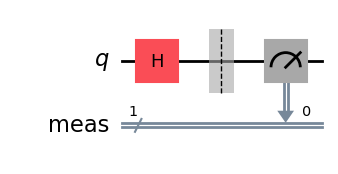

In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1)      # one qubit, starts in |0>
qc.h(0)                     # Hadamard on qubit 0
qc.measure_all()            # read it out
qc.draw(output="mpl")

<div style="border-left:5px solid #059669;background:#ecfdf5;color:#064e3b;padding:12px 16px;border-radius:4px">
<b>⛏️ Task 2.</b> Run the circuit above for <b>1024 shots</b> on the <code>AerSimulator</code> and collect the counts dictionary. <i>Before you run it</i>: write down how many '0's you expect. Then let the checker judge your statistics — it uses a chi-square test, so honest shot noise passes but a wrong circuit fails.
</div>

In [5]:
counts = None  # Initialize
# Run the simulation and assign the counts dictionary to `counts`
# ~~~ YOUR CODE HERE ~~~

print(counts)
checkers.check_counts_close(counts, {"0": 0.5, "1": 0.5})

None


#### 🔬 Analysis

You did **not** get exactly 512/512 — and that's the
point. Each shot is an independent Born-rule sample, so the counts fluctuate
like 1024 coin flips (standard deviation $\approx \sqrt{1024 \cdot \tfrac12 \cdot \tfrac12} = 16$).
This is why every quantum result you'll ever report is *statistics over
shots*, and why the checker asks "is this consistent with 50/50?" rather than
"is this exactly 50/50?". Run the cell again — you'll get slightly different
counts, same verdict.

## 1.4 Steering the amplitudes: the $R_y$ gate

$H$ only ever gives 50/50. To dial in *any* probability we rotate by a chosen
angle with the $R_y(\theta)$ gate — the code version of the widget's θ slider:

$$R_y(\theta)\ket{0} = \cos\tfrac{\theta}{2}\,\ket{0} + \sin\tfrac{\theta}{2}\,\ket{1}.$$

Want a target $P(1)$? Solve $\sin^2\tfrac{\theta}{2} = P(1)$ for $\theta$.
This little trick — *choose an angle, get a distribution* — is the seed of
everything at the Summit: variational algorithms tune exactly such angles
until the statistics encode the answer to a hard problem.

<div style="border-left:5px solid #059669;background:#ecfdf5;color:#064e3b;padding:12px 16px;border-radius:4px">
<b>⛏️ Task 3.</b> Prepare the state with P(1) = 1/4 (the one you hunted for with the slider in Exercise 1). Create a 1-qubit circuit, apply <code>qc3.ry(theta, 0)</code> with the right angle, and check the exact statevector. <br><i>Paper first:</i> solve sin²(θ/2) = 1/4, then code it.
</div>

In [6]:
qc3 = QuantumCircuit(1)
# ~~~ YOUR CODE HERE ~~~

checkers.check_statevector(qc3, targets.M1_TASK3)

#### 🔬 Analysis

From $\sin^2\tfrac{\theta}{2} = \tfrac14$:
$\sin\tfrac{\theta}{2} = \tfrac12 \Rightarrow \tfrac{\theta}{2} = \tfrac{\pi}{6}
\Rightarrow \theta = \tfrac{\pi}{3}$ (that's the ≈ 60° you found on the
slider). The resulting state is

$$\cos\tfrac{\pi}{6}\ket{0} + \sin\tfrac{\pi}{6}\ket{1}
= \tfrac{\sqrt3}{2}\ket{0} + \tfrac12\ket{1},$$

and indeed $\left(\tfrac{\sqrt3}{2}\right)^2 = \tfrac34$, $\left(\tfrac12\right)^2 = \tfrac14$.
Amplitudes → squares → probabilities. Once that chain feels automatic, you
think in quantum.

<div style="border:1px dashed #7c3aed;background:#faf5ff;color:#2e1065;padding:12px 16px;border-radius:8px">
<b>🎨 Make it yours — analogy time.</b> Everyone's brain hooks onto different things. Copy the prompt below into <i>your</i> favorite AI (ChatGPT, Claude, Gemini) and get <b>superposition and measurement</b> explained through <i>your</i> world. The precise definition is baked into the prompt, so the AI can't drift into pop-science myths. Want more control? Use the <a href="https://quantum-ascent-77617.web.app/analogy-studio.html">Analogy Studio</a>.

<pre style="white-space:pre-wrap;background:#fff;border:1px solid #e9d5ff;color:#1e1b2e;border-radius:6px;padding:10px">I'm learning quantum computing. Explain superposition and measurement using an analogy from MY background: [YOUR HOBBY/FIELD HERE].

Ground rules — your analogy MUST respect these facts:
1) A qubit state is two amplitudes (α, β), complex numbers with |α|²+|β|²=1. It is NOT 'both 0 and 1 at once'.
2) Measurement gives outcome 0 with probability |α|² and 1 with probability |β|² (Born rule), and the state then collapses to that outcome.
3) Amplitudes can be negative/complex and can cancel (interference); probabilities cannot.
4) One measurement reveals almost nothing; statistics over many shots reveal the amplitudes.

End by telling me where the analogy breaks down.</pre>
</div>

<div style="border-left:5px solid #7c3aed;background:#f5f3ff;color:#2e1065;padding:12px 16px;border-radius:4px">
<b>🚩 Basecamp 1 reached!</b> You can now write a qubit as amplitudes, predict its statistics with the Born rule, and steer it with $H$ and $R_y$ in Qiskit — prediction before simulation, every time.
</div>

**Next steps:**
1. 🧠 Take the [Basecamp 1 quiz](https://quantum-ascent-77617.web.app/module.html?id=01#quiz) on the website to earn your XP and badge.
2. 🧗 Continue the ascent: **Basecamp 2: Gates & Circuits — where rotations compose and phases start to matter**.

---
*Stuck on a task? Compare with the worked solutions: [`solutions/01_qubits_and_superposition_solutions.ipynb`](solutions/01_qubits_and_superposition_solutions.ipynb). Try honestly first — the struggle is where the learning happens.*